# Data Overview and Initial Analysis

In [4]:
import pickle
import numpy as np

In [6]:
# Load pickle
with open("../data/raw/Bauls.pickle", "rb") as f:
    df = pickle.load(f)

# Check keys
print(df.keys())

# Check shape of every column
for key, value in df.items():
    print(key, value.shape, value.dtype)

C:\Users\ankit\AppData\Local\Temp\ipykernel_22940\1524224155.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


dict_keys(['mel_spec', 'genre', 'state', 'artist', 'gender', 'song', 'source', 'no_of_artists', 'genre_id', 'state_id', 'artist_id', 'gender_id'])
mel_spec (20223, 128, 130) |S32
genre (20223,) |S5
state (20223,) |S11
artist (20223,) |S19
gender (20223,) |S6
song (20223,) |S32
source (20223,) |S68
no_of_artists (20223,) |S1
genre_id (20223,) |S1
state_id (20223,) |S1
artist_id (20223,) |S2
gender_id (20223,) |S1


In [7]:
for key, value in df.items():
    if key != "mel_spec":
        print(f"\n{key}")
        print("Unique values:", len(np.unique(value)))
        print("Values:", np.unique(value))


genre
Unique values: 1
Values: [b'Bauls']

state
Unique values: 1
Values: [b'West Bengal']

artist
Unique values: 9
Values: [b'Amar Pal' b'Babul Supriyo' b'Laxmandas Baul' b'Prahlad Brahmachari'
 b'Purna Das Baul' b'Runa Laila' b'S D Burman' b'Shaan'
 b'Swapna Chakrabarty']

gender
Unique values: 2
Values: [b'Female' b'Male']

song
Unique values: 45
Values: [b'Aamar Ki Holo ' b'Aamar Montake Boli ' b'Aami Ekdino Na Dekhilam Tare'
 b'Allah Megh Dey' b'Amar Ghare Chabi Parer Hate'
 b'Ami Takdoom Takdoom Bajai' b'Bad Hawaya Lege Khanchay Pakhi '
 b'Bali O Nanadi' b'Baro Loker Biti' b'Bhaber Ghare Churi Korle Cholbe'
 b'Bhenge More' b'Biswasbabu Gyanchen Mara' b'Dayal Guru Go '
 b'Dekhechhi Rupsagore Moner Manush' b'Dhik Dhik Aamar E Jibony'
 b'Ebar Pujoy Asbe Jakhun' b'Ei Mahuya Boney' b'Emon Mon Byabsaa'
 b'Golemale Golemale' b'Guru Upay Bolo Na' b'Horinam Diye Jagat Matale'
 b'Je Jan Premer Bhab Janena' b'Jemon Beni Temni Rabey'
 b'Jodi Tor Daak Shune' b'Ka Kha Ga Parte Giye'
 b'Khanch

In [8]:
genre = np.array([x.decode("utf-8") for x in df["genre"]])
state = np.array([x.decode("utf-8") for x in df["state"]])
artist = np.array([x.decode("utf-8") for x in df["artist"]])
gender = np.array([x.decode("utf-8") for x in df["gender"]])
song = np.array([x.decode("utf-8") for x in df["song"]])
source = np.array([x.decode("utf-8") for x in df["source"]])

In [9]:
genre_id = np.array([int(x) for x in df["genre_id"]])
state_id = np.array([int(x) for x in df["state_id"]])
artist_id = np.array([int(x) for x in df["artist_id"]])
gender_id = np.array([int(x) for x in df["gender_id"]])
no_of_artists = np.array([int(x) for x in df["no_of_artists"]])

In [10]:
df["mel_spec"]

array([[[b'-80.0', b'-80.0', b'-80.0', ..., b'-37.854736', b'-37.24803',
         b'-41.973602'],
        [b'-80.0', b'-80.0', b'-79.79688', ..., b'-29.768723',
         b'-32.955696', b'-43.300423'],
        [b'-80.0', b'-80.0', b'-80.0', ..., b'-22.854866',
         b'-36.556034', b'-43.632225'],
        ...,
        [b'-80.0', b'-80.0', b'-80.0', ..., b'-80.0', b'-80.0',
         b'-80.0'],
        [b'-80.0', b'-80.0', b'-80.0', ..., b'-80.0', b'-80.0',
         b'-80.0'],
        [b'-80.0', b'-80.0', b'-80.0', ..., b'-80.0', b'-80.0',
         b'-80.0']],

       [[b'-45.997684', b'-48.971214', b'-60.602173', ...,
         b'-45.074326', b'-43.280838', b'-34.77657'],
        [b'-46.58312', b'-48.897964', b'-59.674477', ..., b'-31.898392',
         b'-30.948883', b'-27.27367'],
        [b'-51.030746', b'-54.233818', b'-62.69132', ..., b'-14.847568',
         b'-15.435707', b'-18.036215'],
        ...,
        [b'-80.0', b'-80.0', b'-80.0', ..., b'-80.0', b'-80.0',
         b'-72.769

In [11]:
mel_spec = df["mel_spec"].astype(np.float32)

print("Shape:", mel_spec.shape)
print("Data type:", mel_spec.dtype)
print("Min:", mel_spec.min())
print("Max:", mel_spec.max())

Shape: (20223, 128, 130)
Data type: float32
Min: -80.0
Max: 7.6293945e-06


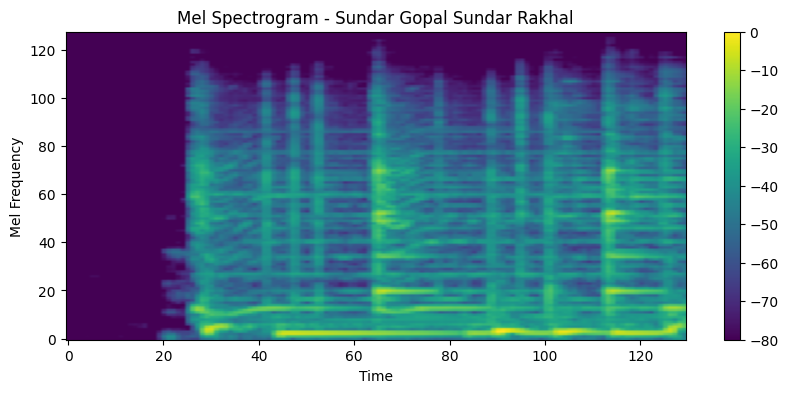

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.imshow(mel_spec[0], aspect="auto", origin="lower")
plt.title(f"Mel Spectrogram - {song[0]}")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.colorbar()
plt.show()

In [13]:
unique_songs, song_counts = np.unique(song, return_counts=True)

print("Number of unique songs:", len(unique_songs))

for s, c in zip(unique_songs, song_counts):
    print(s, ":", c)

Number of unique songs: 45
Aamar Ki Holo  : 389
Aamar Montake Boli  : 701
Aami Ekdino Na Dekhilam Tare : 333
Allah Megh Dey : 497
Amar Ghare Chabi Parer Hate : 327
Ami Takdoom Takdoom Bajai : 507
Bad Hawaya Lege Khanchay Pakhi  : 391
Bali O Nanadi : 457
Baro Loker Biti : 353
Bhaber Ghare Churi Korle Cholbe : 649
Bhenge More : 457
Biswasbabu Gyanchen Mara : 1045
Dayal Guru Go  : 489
Dekhechhi Rupsagore Moner Manush : 543
Dhik Dhik Aamar E Jibony : 391
Ebar Pujoy Asbe Jakhun : 275
Ei Mahuya Boney : 373
Emon Mon Byabsaa : 369
Golemale Golemale : 385
Guru Upay Bolo Na : 397
Horinam Diye Jagat Matale : 559
Je Jan Premer Bhab Janena : 345
Jemon Beni Temni Rabey : 369
Jodi Tor Daak Shune : 539
Ka Kha Ga Parte Giye : 351
Khanchar Bhitar Achin Pakhi : 391
Khepa Tui Na Jene : 307
Man Porey Bhalobashey : 487
Menokaa Maathay Dilo Ghomtaa : 349
Moner Moton Pagol Pelam Na : 765
Oki Bondhu Kajal Bharmara Re : 391
Prabhat Samoy Kaale : 335
Rai Jago Go : 597
Rai Jago Rai Jago Bole : 375
Sabe Bale Lalan

In [16]:
# Total number of unique songs
unique_songs = np.unique(song)

print("Total unique songs:", len(unique_songs))

# Find gender associated with each unique song
song_gender = {}

for s in unique_songs:
    genders = np.unique(gender[song == s])
    song_gender[s] = genders

# Count songs by gender
male_songs = [s for s in unique_songs if "Male" in song_gender[s]]
female_songs = [s for s in unique_songs if "Female" in song_gender[s]]

print("Unique songs sung by Male:", len(male_songs))
print("Unique songs sung by Female:", len(female_songs))

Total unique songs: 45
Unique songs sung by Male: 35
Unique songs sung by Female: 10
